# Going deeper with Convolutional Neural Networks (`main_report.ipynp`)

In [1]:
import torchvision.transforms as transforms
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch

import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


from tqdm import tqdm

## Seeding ensures reproducibilit, device is ensuring we send it to GPU 
torch.manual_seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Transform to Grayscale, then to tensor, then nomalise
transform = transforms.Compose(
    [transforms.Grayscale(),
     transforms.ToTensor(),
     transforms.Normalize((0.5), (0.5)),
    ])

## Call in the data from the files, and their split , further down we will split further for test. 
trainval_dataset = torchvision.datasets.ImageFolder('chest_xray/trainval', transform = transform)
train_portion = 0.8
val_portion = 0.2

## split the indexes and targets 
all_indexes = np.arange(len(trainval_dataset))
all_targets = trainval_dataset.targets

## Split the dataset indexes into train and val idx, Assign the train size, stratify ensures class distribution is even an drandom state for reproducibility.  
train_idx, val_idx = train_test_split(all_indexes, train_size=train_portion, stratify = all_targets, random_state = 0)

## Create the separate bookcases and store them. Input the dataset and the train idx and val idx that will be in the bookcase. 
train_dataset = torch.utils.data.Subset(trainval_dataset, train_idx)
val_dataset = torch.utils.data.Subset(trainval_dataset, val_idx)

## Assign the test dataset, no need to split. 
test_dataset = torchvision.datasets.ImageFolder('chest_xray/test', transform = transform)

## Batch size is the amount of images we iterate over before we update weights. 
## So we update the weight after 16 images until we go through the whole dataset. when the whole dataset is completed we complete an epoch. 
batch_size = 16


## these are my loades into the model, insert the datasets, batch size is as stated before, you only shuffle 
## training set so it doesnt learn on loading order, number of workers is just helpers, that prepare and load. 
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers = 2)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers = 2)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers = 2)


In [10]:
## Load my stored train/val loss and acc values from the dev file to reproduce the val/acc graph. 

history = np.load("training_history.npz")

train_loss = history["train_loss"]
train_acc = history["train_acc"]
val_loss = history["val_loss"]
val_acc = history["val_acc"]

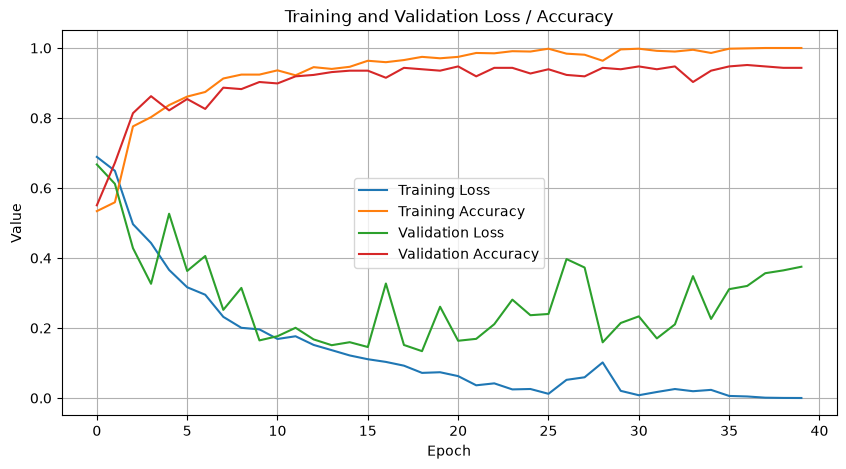

In [11]:
## Plot my loss and accuracy graph from the developoment on finalised weights. 

plt.figure(figsize=(10, 5))

plt.plot(train_loss, label="Training Loss")
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_loss, label="Validation Loss")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Training and Validation Loss / Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

In [6]:
## Load the model weights i saved from the Dev file. 
from model import load_vgg

## Load the final weights.
vgg = load_vgg()
vgg = vgg.to(device)
vgg.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2304,

In [4]:
# Perform any prediction / generate any figure you might need for your report

In [12]:
## Set my ground truths, and the test predictions lists. 
gt_test = []
test_pred = []

## Ensure we dont calculate the gradients or update the model 
with torch.no_grad():

    ## take the input(images) and labels(Correct answers) and loop them through the below 
    for inputs, labels in tqdm(testloader, total=len(testloader)):

        ## Send the inputs to where my model is loaded
        inputs = inputs.to(device)

        ## place the inputs(batch of images) through the model 
        outputs = vgg(inputs)

        ## Use argmax to confirm the final prediction
        predicted = torch.argmax(outputs, dim=1)

        ## Store the predictions and ground truths 
        test_pred.extend(predicted.cpu().tolist())
        gt_test.extend(labels.tolist())

100%|██████████| 37/37 [00:00<00:00, 46.84it/s]


In [8]:
## Produce the classification report on the test set. 

from sklearn.metrics import classification_report

print("Test Classification Report")

print(
    classification_report(
        gt_test,
        test_pred,
        target_names=test_dataset.classes
    )
)

Test Classification Report
              precision    recall  f1-score   support

      NORMAL       0.93      0.92      0.92       278
   PNEUMONIA       0.93      0.94      0.93       313

    accuracy                           0.93       591
   macro avg       0.93      0.93      0.93       591
weighted avg       0.93      0.93      0.93       591



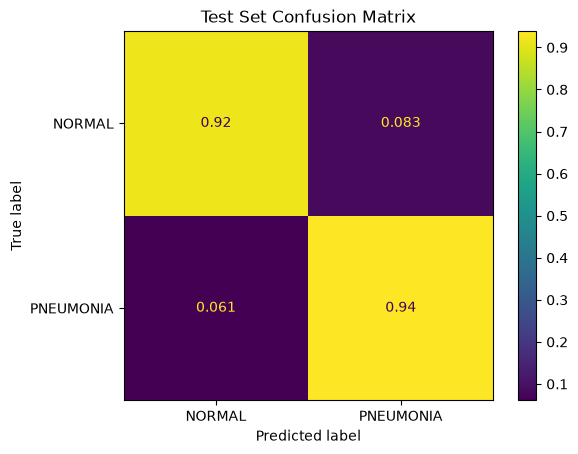

In [13]:
## Produce the confusion matrix.

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    gt_test,
    test_pred,
    display_labels=test_dataset.classes,
    normalize="true"
)

plt.title("Test Set Confusion Matrix")
plt.show()